In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [3]:
# Creating dummy sales dataset
np.random.seed(42)

data = {
    'Date': pd.date_range(start='2024-01-01', periods=100, freq='D'),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], 100),
    'Product': np.random.choice(['Laptop', 'Phone', 'Tablet'], 100),
    'Units Sold': np.random.randint(10, 200, 100),
    'Unit Price': np.random.choice([300, 500, 800, 1000], 100)
    }

In [4]:
df = pd.DataFrame(data)
df

,Date,Region,Product,Units Sold,Unit Price
0,2024-01-01,East,Tablet,37,1000
1,2024-01-02,West,Phone,37,1000
2,2024-01-03,North,Phone,117,500
3,2024-01-04,East,Phone,53,1000
4,2024-01-05,East,Phone,93,300
...,...,...,...,...,...
95,2024-04-05,South,Laptop,160,800
96,2024-04-06,South,Phone,168,1000
97,2024-04-07,West,Laptop,51,300
98,2024-04-08,South,Laptop,108,300


In [6]:
df['Total Sales'] = df['Units Sold'] * df['Unit Price']

In [7]:
df.head()

,Date,Region,Product,Units Sold,Unit Price,Total Sales
0,2024-01-01,East,Tablet,37,1000,37000
1,2024-01-02,West,Phone,37,1000,37000
2,2024-01-03,North,Phone,117,500,58500
3,2024-01-04,East,Phone,53,1000,53000
4,2024-01-05,East,Phone,93,300,27900


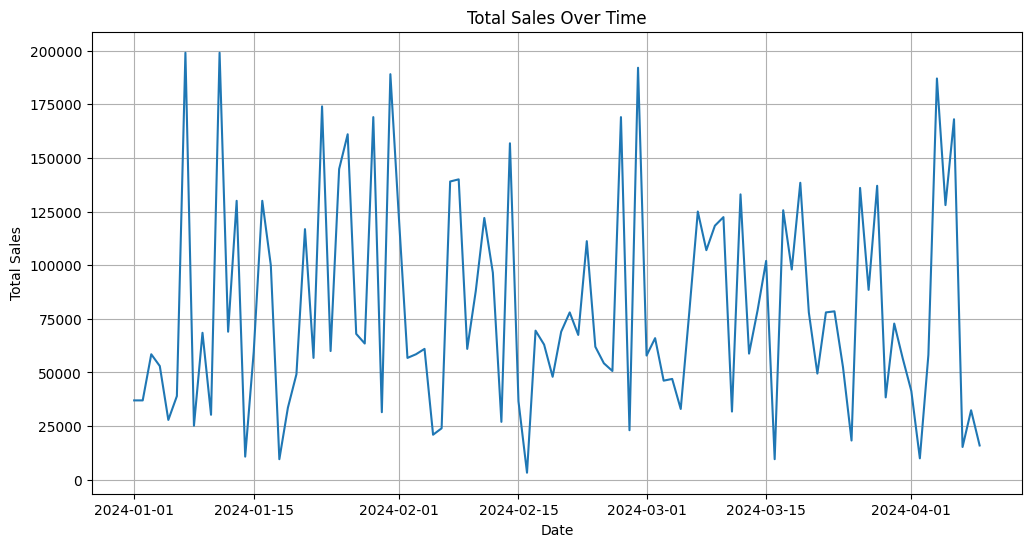

In [8]:

# Total sales over time
df_grouped = df.groupby('Date')['Total Sales'].sum()
plt.figure(figsize=(12, 6))
plt.plot(df_grouped.index, df_grouped.values)
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()


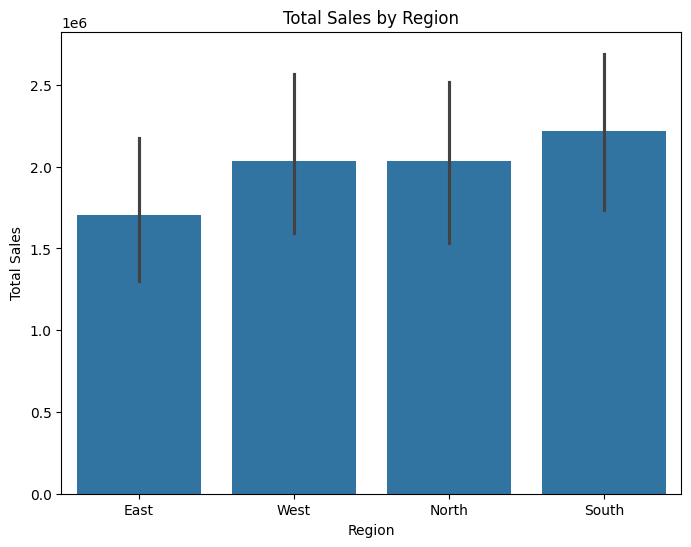

In [9]:
# Total sales by region
plt.figure(figsize=(8, 6))
sns.barplot(x='Region', y='Total Sales', data=df, estimator=np.sum)
plt.title('Total Sales by Region')
plt.show()


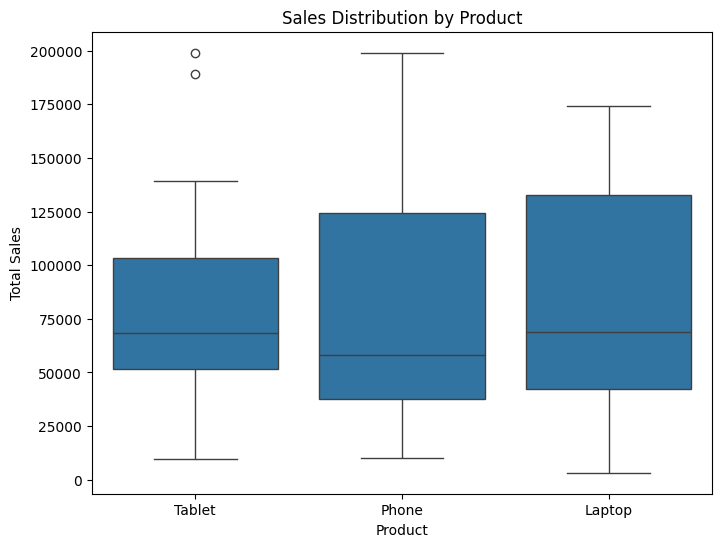

In [10]:
# Sales by product
plt.figure(figsize=(8, 6))
sns.boxplot(x='Product', y='Total Sales', data=df)
plt.title('Sales Distribution by Product')
plt.show()


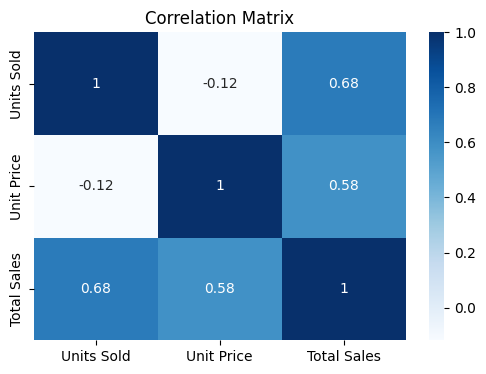

In [11]:
# Correlation heatmap


plt.figure(figsize=(6, 4))
sns.heatmap(df[['Units Sold', 'Unit Price', 'Total Sales']].corr(), annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()


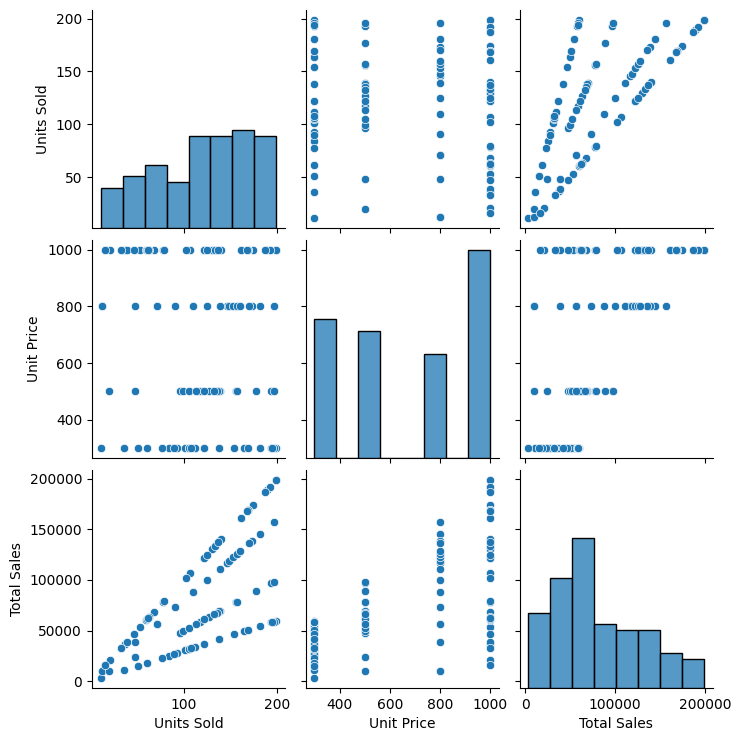

In [12]:
# Pairplot

sns.pairplot(df[['Units Sold', 'Unit Price', 'Total Sales']])
plt.show()


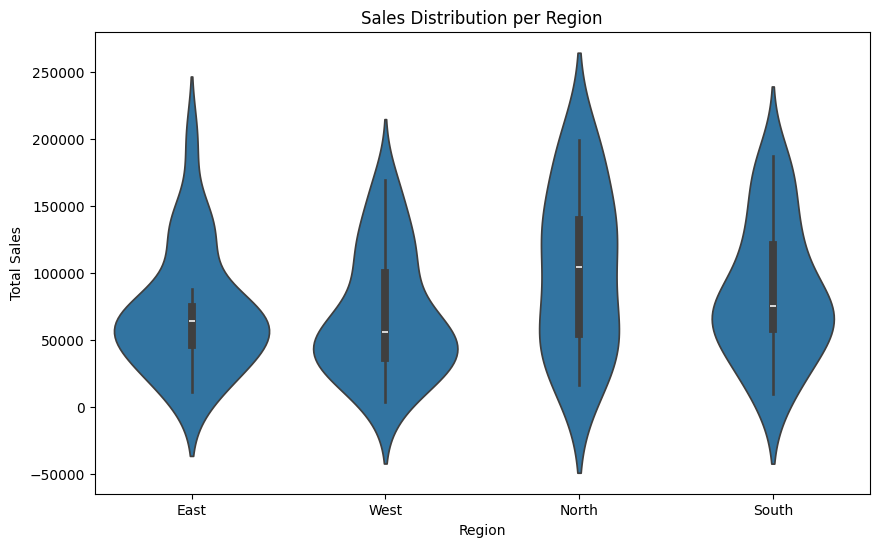

In [13]:
# Violin plot of sales by region

plt.figure(figsize=(10,6))
sns.violinplot(x='Region', y='Total Sales', data=df)
plt.title('Sales Distribution per Region')
plt.show()


In [14]:
#  Predicting Total Sales using Linear Regression

# Feature engineering

df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month


In [15]:

features = df[['Units Sold', 'Unit Price', 'Day', 'Month']]
target = df['Total Sales']


In [16]:

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, predictions)
print(f'Mean Squared Error: {mse:.2f}')

Mean Squared Error: 179586600.14


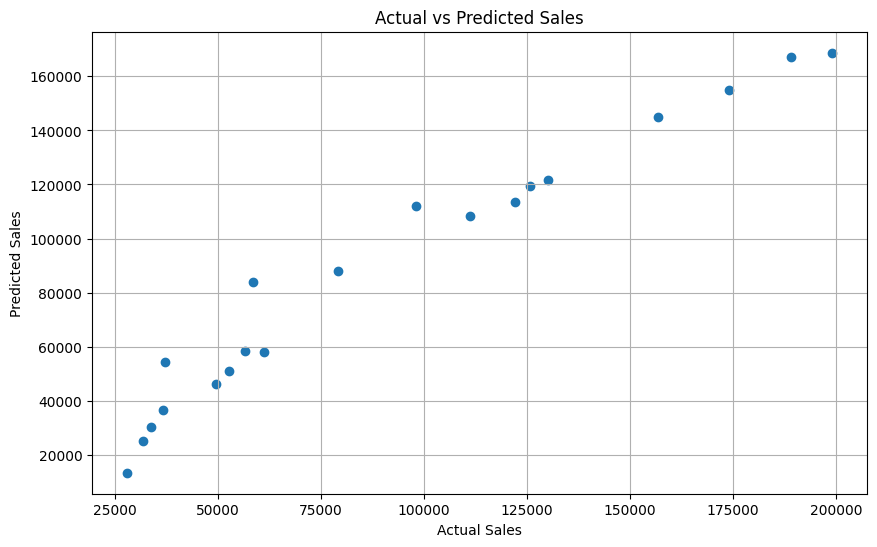

In [17]:
#  PLOT ACTUAL VS PREDICTED SALES


plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.grid(True)
plt.show()


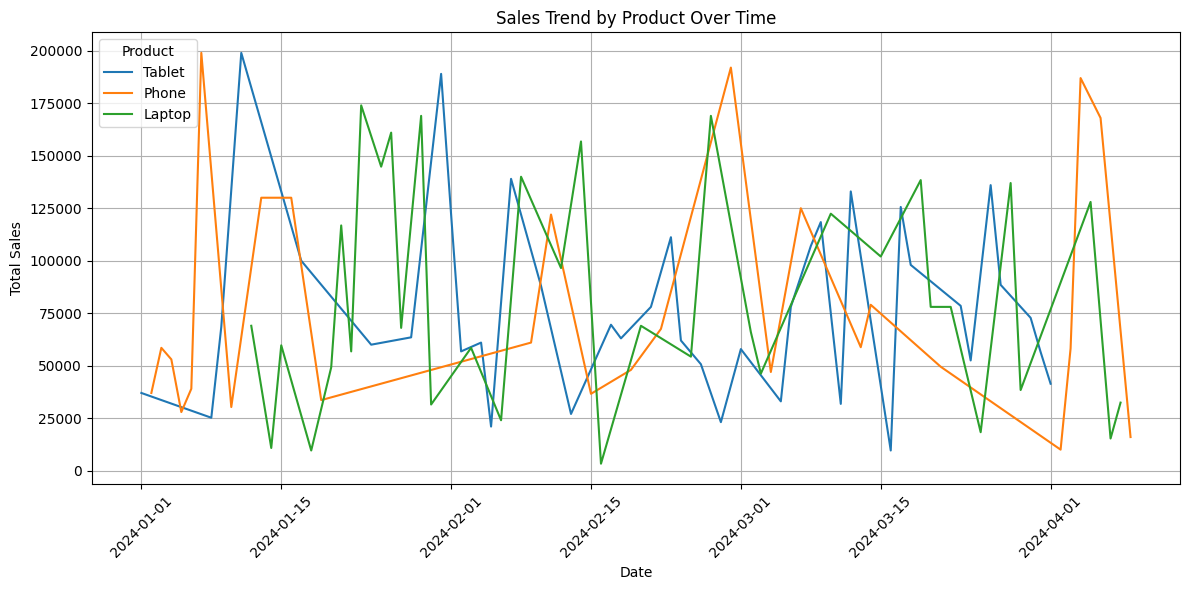

In [18]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Total Sales', hue='Product')
plt.title('Sales Trend by Product Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


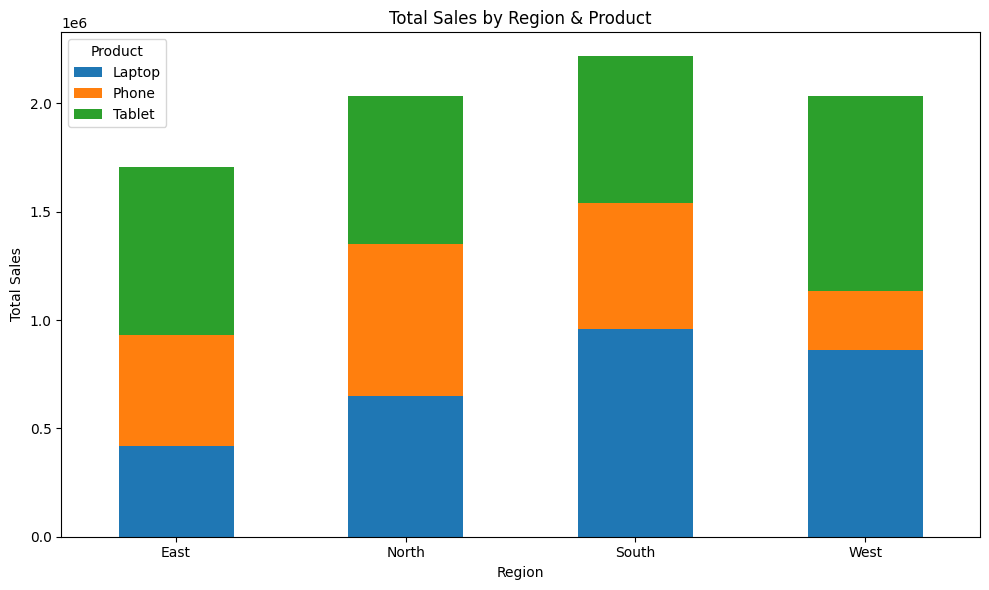

In [19]:
region_product = df.groupby(['Region', 'Product'])['Total Sales'].sum().unstack()

region_product.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Total Sales by Region & Product')
plt.ylabel('Total Sales')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.legend(title='Product')
plt.tight_layout()
plt.show()


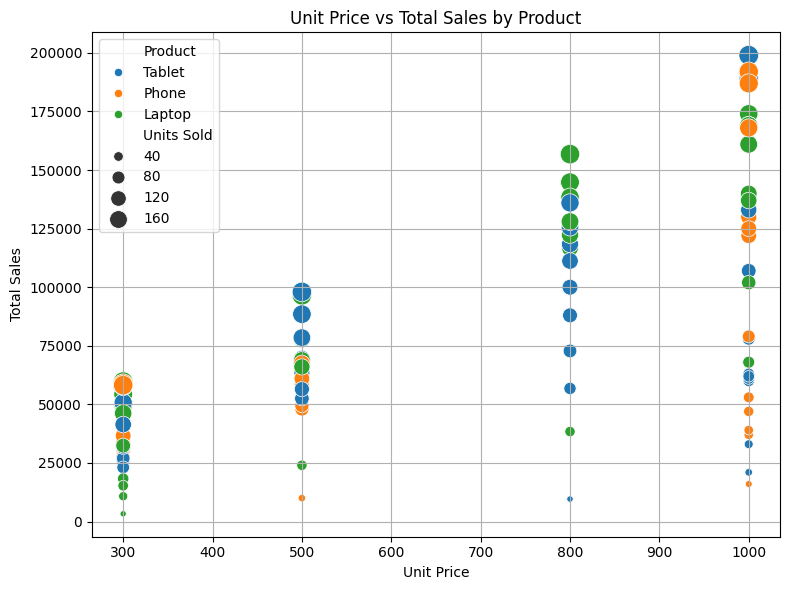

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Unit Price', y='Total Sales', hue='Product', size='Units Sold', sizes=(20, 200))
plt.title('Unit Price vs Total Sales by Product')
plt.grid(True)
plt.tight_layout()
plt.show()


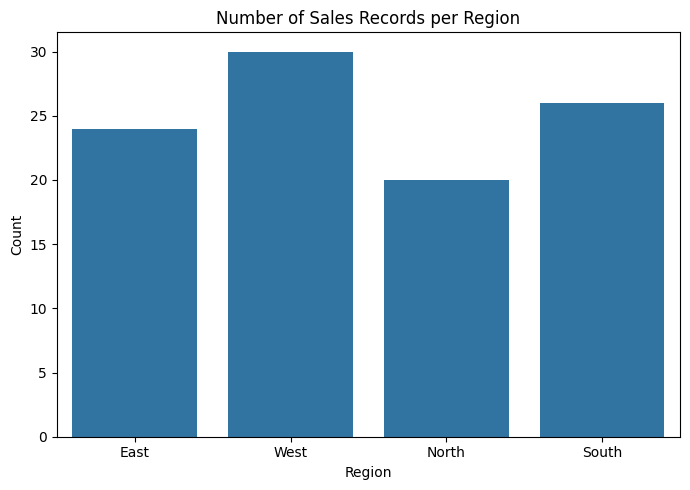

In [21]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Region')
plt.title('Number of Sales Records per Region')
plt.ylabel('Count')
plt.xlabel('Region')
plt.tight_layout()
plt.show()


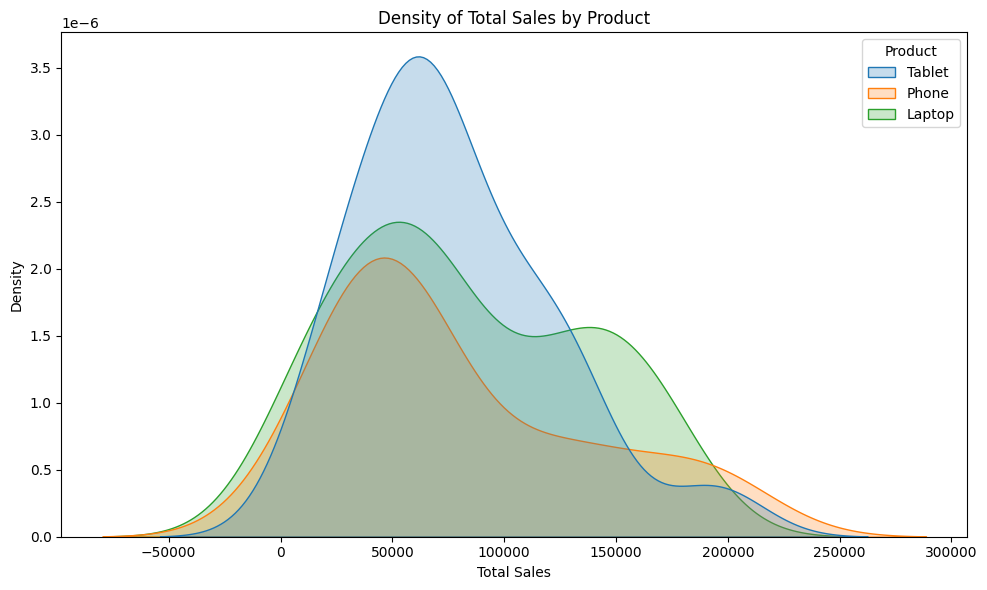

In [22]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Total Sales', hue='Product', fill=True)
plt.title('Density of Total Sales by Product')
plt.tight_layout()
plt.show()


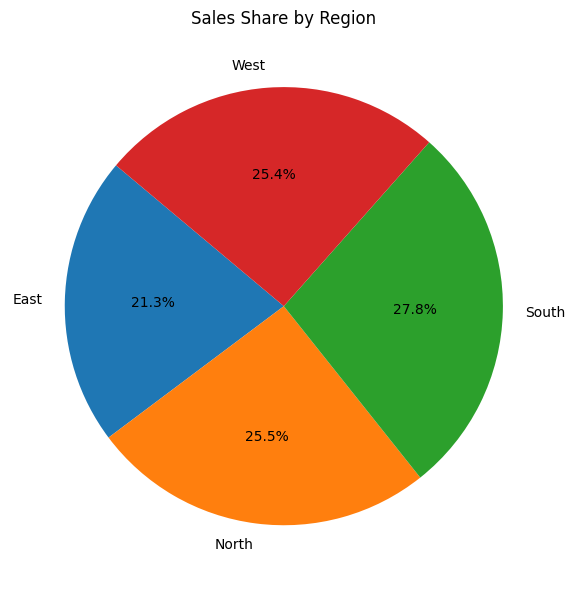

In [23]:
sales_by_region = df.groupby('Region')['Total Sales'].sum()
plt.figure(figsize=(6,6))
plt.pie(sales_by_region, labels=sales_by_region.index, autopct='%1.1f%%', startangle=140)
plt.title('Sales Share by Region')
plt.tight_layout()
plt.show()


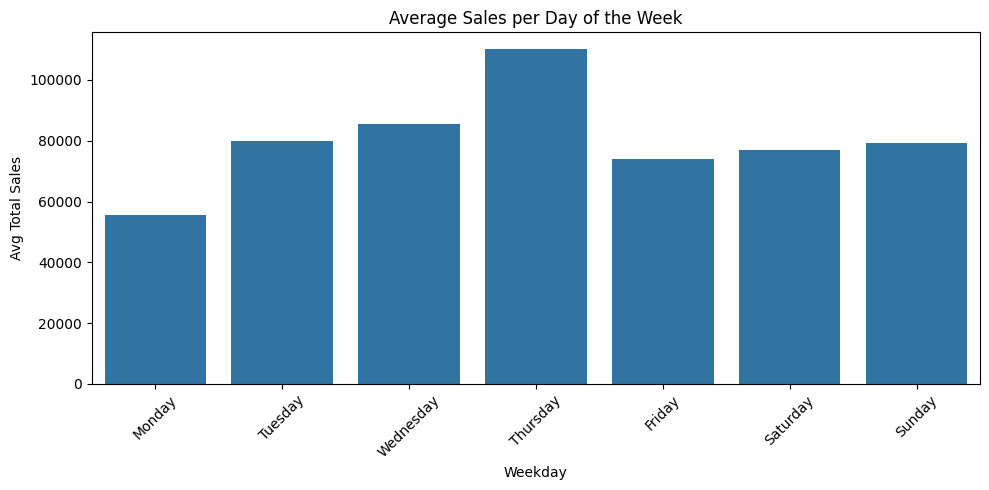

In [24]:
df['Weekday'] = df['Date'].dt.day_name()
weekday_sales = df.groupby('Weekday')['Total Sales'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(10,5))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values)
plt.title('Average Sales per Day of the Week')
plt.ylabel('Avg Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
